# **1- Libraries**

In [103]:
pip install geopy

In [104]:
pip install folium

In [105]:
pip install requests

In [106]:
!pip install -q lightgbm

In [107]:
!pip install -q catboost

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as plt
import plotly.express as px
import plotly.graph_objects as go
from datetime import timedelta

import warnings
warnings.filterwarnings('ignore')
import os

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from geopy.geocoders import Nominatim
import folium
from folium.plugins import MarkerCluster
import requests
from tqdm.notebook import tqdm
import time
from time import sleep
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# **2- Data Overview**

In [109]:
train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')

In [110]:
train.head()

,id,request_date,pickup_city,destination_city,accepted_date,started_date,rider,driver,trip_distance,driver2rider_distance,used_discount,trip_status,trip_finished_date,rider_rating,driver_rating,rider_cancel_reason,driver_cancel_reason,discount_amount,trip_fee
0,LVwq2xeA5mMt,2021-01-30 14:06:19.94,Constantine,Constantine,2021-01-30 14:07:04.707,NaN,E1B3rg1jOiBF,DVwusPupJeU4,16035,1927,0,NOT_FINISHED,NaN,NaN,NaN,NaN,NaN,NaN,511
1,U9CuIIRyArx0,2021-05-18 07:54:39.922,Alger,Alger,2021-05-18 07:55:05.362,2021-05-18 08:03:23.664,u7zilHWibXpk,Mv2dXvQt5e5i,12031,1884,0,FINISHED,2021-05-18 08:32:03.611,4.0,5.0,NaN,NaN,NaN,579
2,ke1gwcPZ93Nl,2021-03-05 13:17:24.999,Oran,Oran,NaN,NaN,NmumknIUfHYy,yOf6NbYVTVAl,16812,994,0,NOT_FINISHED,NaN,NaN,NaN,NaN,NaN,NaN,706
3,djk2iJ9DxEsC,2021-02-24 14:08:57.592,Alger,Alger,2021-02-24 14:09:35.139,2021-02-24 14:15:15.67,lM2VjdqUB1Eb,L0b1fBxbKELj,6759,1037,0,FINISHED,2021-02-24 14:19:18.31,5.0,5.0,NaN,NaN,NaN,343
4,FmVbgMcD4a5r,2021-03-08 09:14:24.922,Alger,Alger,2021-03-08 09:14:58.244,2021-03-08 09:49:02.868,xe9ExnoJcI9a,VNJpNZpa9A1Q,11628,1174,1,FINISHED,2021-03-08 09:49:04.071,5.0,5.0,UNDEFINED,UNDEFINED,500.0,517


In [111]:
test.head()

,id,request_date,pickup_city,destination_city,accepted_date,started_date,rider,driver,trip_distance,driver2rider_distance,used_discount,trip_status,trip_finished_date,rider_rating,driver_rating,rider_cancel_reason,driver_cancel_reason,discount_amount
0,N7aPBXp0Flm5,2021-06-27 08:52:14.396,Alger,Alger,2021-06-27 08:53:06.243,NaN,EIdLWfrGHFCa,6VwbRFt8nlkk,305,85,0,NOT_FINISHED,NaN,NaN,NaN,NaN,NaN,NaN
1,tOwj3FIL1IzN,2021-06-07 14:17:31.774,Alger,Alger,2021-06-07 14:18:18.363,2021-06-07 14:29:24.456,QFi4jOwMNjPr,eYnWva0Z38su,19812,1670,0,FINISHED,2021-06-07 14:50:46.282,5.0,5.0,NaN,NaN,NaN
2,DPHis6MSuc2R,2021-06-10 12:26:58.441,Alger,Alger,2021-06-10 12:30:59.679,NaN,EjU9WldJx4YE,MhxlpBF3aXEa,6413,988,1,NOT_FINISHED,NaN,NaN,NaN,NaN,NaN,500.0
3,uJTNO4TrLHMV,2021-06-22 07:49:42.712,Tipaza,Alger,NaN,NaN,0Frx3EFp91pw,yOf6NbYVTVAl,25698,1457,1,NOT_FINISHED,NaN,NaN,NaN,NaN,NaN,9999.0
4,jpyQzGklCqrU,2021-06-10 11:04:24.347,Alger,Alger,NaN,NaN,GpQb0nV4AnyV,yOf6NbYVTVAl,8518,1128,1,NOT_FINISHED,NaN,NaN,NaN,NaN,NaN,500.0


2-1- Checking data similarities

In [112]:
dtype_train = pd.DataFrame({
    "Column": train.columns,
    "Data Type": train.dtypes,
    "Unique Values": train.nunique(),
    "Missing values":train.isnull().sum()

})

dtype_train

,Column,Data Type,Unique Values,Missing values
id,id,object,723406,0
request_date,request_date,object,723351,0
pickup_city,pickup_city,object,43,0
destination_city,destination_city,object,48,0
accepted_date,accepted_date,object,485024,238357
started_date,started_date,object,332200,391184
rider,rider,object,192219,0
driver,driver,object,12558,0
trip_distance,trip_distance,int64,57721,0
driver2rider_distance,driver2rider_distance,int64,12057,0


In [113]:
dtype_test = pd.DataFrame({
    "Column": test.columns,
    "Data Type": test.dtypes,
    "Unique Values": test.nunique(),
    "Missing values":test.isnull().sum()

})

dtype_test

,Column,Data Type,Unique Values,Missing values
id,id,object,276469,0
request_date,request_date,object,276450,0
pickup_city,pickup_city,object,22,0
destination_city,destination_city,object,49,0
accepted_date,accepted_date,object,168708,107757
started_date,started_date,object,112855,163608
rider,rider,object,100691,0
driver,driver,object,8312,0
trip_distance,trip_distance,int64,42910,0
driver2rider_distance,driver2rider_distance,int64,6725,0


In [114]:
#Convert Object to Datetime

date_cols = ['request_date', 'accepted_date', 'started_date', 'trip_finished_date']

train[date_cols] = train[date_cols].apply(
    lambda col: pd.to_datetime(col, errors='coerce')
)

test[date_cols] = test[date_cols].apply(
    lambda col: pd.to_datetime(col, errors='coerce')
)

The NULL values correspond to trips that were not accepted, started, or completed. This explains the missing values in variables such as the driver information, rider ratings, and fees. Additionally, since some cancellation reason fields are missing, it indicates that these trips were not cancelled.

Therefore, these missing values are not data errors or inconsistencies; they reflect the natural workflow of the trip process. Consequently, they should not be removed, as deleting these rows would result in a loss of meaningful information. Instead, the missing values should be handled according to their underlying meaning.

In [115]:
train.groupby("trip_status")["driver2rider_distance"].mean()

,driver2rider_distance
trip_status,
FINISHED,1286.225494
NOT_FINISHED,1803.489376


# **3- Descriptive Statistics**

## 3-1- Finished and Unfinished trips

### **3-1-1- Overall**

In [116]:
status_counts = train["trip_status"].value_counts().reset_index()
status_counts.columns = ["trip_status", "count"]

fig = px.pie(
    status_counts, names="trip_status", values="count",
    title="Finished vs Not Finished Trips (Overall)",
    color="trip_status",
    color_discrete_map={"FINISHED": "seagreen", "NOT_FINISHED": "indianred"}
)
fig.show()

print(status_counts)

    trip_status   count
0  NOT_FINISHED  389792
1      FINISHED  333614


### **3-1-2- Per month**

In [119]:
train["month"] = train["request_date"].dt.month

monthly_stats = train.groupby(["month", "trip_status"]).agg(
    count=("id", "count"),
    avg_distance=("driver2rider_distance", "mean"),
    avg_fee=("trip_fee", "mean")
).reset_index()

month_names = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
monthly_stats["month_name"] = monthly_stats["month"].map(month_names)

fig = px.bar(
    monthly_stats.sort_values("month"), x="month_name", y="count", color="trip_status", barmode="group",
    title="Finished vs Not Finished Trips per Month (2021)",
    color_discrete_map={"FINISHED": "seagreen", "NOT_FINISHED": "indianred"}
)
fig.show()

### **3-1-3- Time of day**

In [120]:
train["hour"] = train["request_date"].dt.hour

hourly = train.groupby(["hour", "trip_status"]).size().reset_index(name="count")

fig = px.line(
    hourly, x="hour", y="count", color="trip_status", markers=True,
    title="Trips by Hour of Day (Finished vs Not Finished)",
    color_discrete_map={"FINISHED": "seagreen", "NOT_FINISHED": "indianred"}
)
fig.show()

busiest_hour_overall = train["hour"].value_counts().idxmax()
busiest_hour_finished = train[train["trip_status"] == "FINISHED"]["hour"].value_counts().idxmax()
print(f"Busiest hour overall (most requests): {busiest_hour_overall}:00")
print(f"Busiest hour for FINISHED trips: {busiest_hour_finished}:00")


Busiest hour overall (most requests): 15.0:00
Busiest hour for FINISHED trips: 13.0:00


### **3-1-4- By city**

In [121]:
top_requested_cities = train["pickup_city"].value_counts().head(10).reset_index()
top_requested_cities.columns = ["pickup_city", "count"]

fig = px.bar(
    top_requested_cities, x="pickup_city", y="count",
    title="Top 10 Cities by Total Requested Trips"
)
fig.show()

# same idea split by status, only top 10 cities (48 cities side by side would be unreadable)
city_status = train.groupby(["pickup_city", "trip_status"]).size().reset_index(name="count")
top10_cities = top_requested_cities["pickup_city"]
city_status_top10 = city_status[city_status["pickup_city"].isin(top10_cities)]

fig = px.bar(
    city_status_top10, x="pickup_city", y="count", color="trip_status", barmode="group",
    title="Finished vs Not Finished Trips - Top 10 Cities",
    color_discrete_map={"FINISHED": "seagreen", "NOT_FINISHED": "indianred"}
)
fig.show()

print("City with most REQUESTED trips:", train["pickup_city"].value_counts().idxmax())
print("City with most FINISHED trips:", train[train["trip_status"] == "FINISHED"]["pickup_city"].value_counts().idxmax())
print("City with most NOT_FINISHED trips:", train[train["trip_status"] == "NOT_FINISHED"]["pickup_city"].value_counts().idxmax())

City with most REQUESTED trips: Alger
City with most FINISHED trips: Alger
City with most NOT_FINISHED trips: Alger


# **4- Explanatory Data Analysis**

## ****4-1- Costumers' Segmentation****




In [122]:
rider_segmentation = train.groupby("rider").agg(
    total_trips=("id", "count"),
    completed_trips=("trip_status", lambda x: (x=="FINISHED").sum()),
    cancelled_trips=("trip_status", lambda x: (x=="NOT_FINISHED").sum()),
    avg_distance=("driver2rider_distance", "mean"),
    avg_fee=("trip_fee", "mean"),
    total_spending=("trip_fee", "sum")
)

rider_segmentation["completion_rate"] = (
    rider_segmentation["completed_trips"] /
    rider_segmentation["total_trips"]
)

rider_segmentation["cancellation_rate"] = (
    rider_segmentation["cancelled_trips"] /
    rider_segmentation["total_trips"]
)

In [123]:
features = [
    "total_trips",
    "completion_rate",
    "cancellation_rate",
    "avg_distance",
    "total_spending"
]

In [124]:
X = rider_segmentation[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

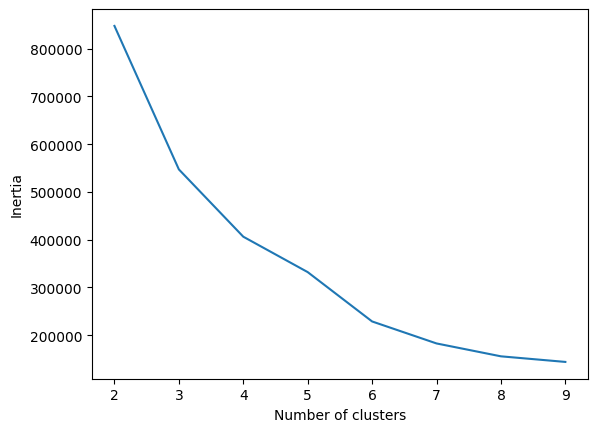

In [125]:
inertia = []

for k in range(2,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2,10), inertia)
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

In [126]:
kmeans = KMeans(n_clusters=4, random_state=42)

rider_segmentation["segment"] = kmeans.fit_predict(X_scaled)

In [127]:
rider_segmentation.groupby("segment")[features].mean()

,total_trips,completion_rate,cancellation_rate,avg_distance,total_spending
segment,,,,,
0,2.762051,0.170083,0.829917,1707.978055,2.036088e+03
1,20.019180,0.481533,0.518467,1489.531517,1.420918e+04
2,2.507158,0.914016,0.085984,1350.341733,1.339867e+03
3,153.000000,0.000000,1.000000,78662.665406,6.357543e+06


**Key Insights** :

*   The most important segment is Segment 1 because it contains frequent riders with high spending but poor trip completion rates. Improving their experience could have the highest business impact.

* Segment 2 represents satisfied customers who could be converted into loyal users.

* Segments 0 and 3 require investigation due to their very high cancellation rates.

The segmentation analysis identified four rider profiles based on usage frequency, trip success rate, cancellation behavior, distance traveled, and spending. The results highlight a group of frequent but dissatisfied customers who generate significant revenue while experiencing a high cancellation rate. This segment represents a strategic opportunity for improving service quality and customer retention. In addition, an anomalous segment with extreme values was detected, suggesting the presence of outliers or abnormal records requiring further investigation.

## **4-2- Driver-level KPI**

In [128]:
driver_perf = train.groupby("driver").agg(
    total_trips=("id", "count"),
    completed_trips=("trip_status", lambda x: (x=="FINISHED").sum()),
    cancelled_trips=("trip_status", lambda x: (x=="NOT_FINISHED").sum()),
    avg_rating=("rider_rating", "mean"),
    total_revenue=("trip_fee", "sum"),
    avg_distance=("trip_distance", "mean")
)

driver_perf["completion_rate"] = (
    driver_perf["completed_trips"] /
    driver_perf["total_trips"]
)

driver_perf["cancellation_rate"] = (
    driver_perf["cancelled_trips"] /
    driver_perf["total_trips"]
)

driver_perf["avg_revenue_per_trip"] = (
    driver_perf["total_revenue"] /
    driver_perf["completed_trips"]
)

In [129]:
kpis = [
    "completion_rate",
    "avg_rating",
    "total_revenue",
    "cancellation_rate"
]

scaler = MinMaxScaler()

driver_perf[kpis] = scaler.fit_transform(
    driver_perf[kpis]
)

driver_perf["performance_score"] = (
    0.4 * driver_perf["completion_rate"]
    + 0.3 * driver_perf["avg_rating"]
    + 0.2 * driver_perf["total_revenue"]
    - 0.1 * driver_perf["cancellation_rate"]
)

In [130]:
ranking = driver_perf.sort_values(
    "performance_score",
    ascending=False
)

ranking.head(10)

,total_trips,completed_trips,cancelled_trips,avg_rating,total_revenue,avg_distance,completion_rate,cancellation_rate,avg_revenue_per_trip,performance_score
driver,,,,,,,,,,
u9LoXv5aWbmy,6,6,0,1.0,0.000157,112394.000000,1.0,0.0,3562.833333,0.700031
TtHDgr7fRggR,9,9,0,1.0,0.000064,41884.888889,1.0,0.0,973.111111,0.700013
8rSGHQh5DKZH,3,3,0,1.0,0.000057,92590.666667,1.0,0.0,2598.666667,0.700011
0u0JoeOov63E,9,9,0,1.0,0.000052,22768.000000,1.0,0.0,797.222222,0.700010
Fx2SknAOFe7Q,8,8,0,1.0,0.000034,15454.125000,1.0,0.0,597.750000,0.700007
wz1HhdXy6Ouc,2,2,0,1.0,0.000034,58343.500000,1.0,0.0,2362.000000,0.700007
tHl8islvtz4Q,8,8,0,1.0,0.000032,12038.875000,1.0,0.0,549.375000,0.700006
PY6mqfIt6wBp,6,6,0,1.0,0.000030,22732.000000,1.0,0.0,701.000000,0.700006
VjzBlZ1OGaUR,6,6,0,1.0,0.000026,18865.666667,1.0,0.0,614.833333,0.700005


In [131]:
driver_perf["performance_level"] = pd.cut(
    driver_perf["performance_score"],
    bins=3,
    labels=["Low", "Medium", "High"]
)

driver_perf["performance_level"].value_counts()

,count
performance_level,
High,7222
Medium,4499
Low,73


## **4-3- Interactive Geographical Analysis**

In [132]:
geolocator = Nominatim(user_agent="ride_analysis")

# Fallback used only if Nominatim fails/times out/rate-limits
algeria_city_coords_fallback = {
    "Adrar": (27.8702, -0.2891), "Alger": (36.7538, 3.0588), "Annaba": (36.9000, 7.7667),
    "Aïn Defla": (36.2642, 1.9672), "Aïn Témouchent": (35.2975, -1.1404), "Batna": (35.5559, 6.1741),
    "Biskra": (34.8500, 5.7333), "Blida": (36.4700, 2.8300), "Bordj Bou Arreridj": (36.0730, 4.7608),
    "Bouira": (36.3800, 3.9000), "Boumerdès": (36.7667, 3.4667), "Béchar": (31.6167, -2.2167),
    "Béjaïa": (36.7500, 5.0833), "Chlef": (36.1667, 1.3333), "Constantine": (36.3650, 6.6147),
    "Djelfa": (34.6667, 3.2500), "El Bayadh": (33.6833, 1.0167), "El Oued": (33.3683, 6.8672),
    "El Tarf": (36.7667, 8.3167), "Ghardaïa": (32.4902, 3.6730), "Guelma": (36.4611, 7.4256),
    "Illizi": (26.4833, 8.4667), "Jijel": (36.8200, 5.7667), "Khenchela": (35.4358, 7.1433),
    "Laghouat": (33.8000, 2.8667), "M'Sila": (35.7000, 4.5417), "Mascara": (35.3967, 0.1400),
    "Mila": (36.4500, 6.2600), "Mostaganem": (35.9333, 0.0900), "Médéa": (36.2639, 2.7539),
    "Naâma": (33.2667, -0.3167), "Oran": (35.6969, -0.6331), "Ouargla": (31.9500, 5.3333),
    "Oum El Bouaghi": (35.8778, 7.1133), "Relizane": (35.7372, 0.5561), "Saïda": (34.8303, 0.1517),
    "Sidi Bel Abbès": (35.1900, -0.6300), "Skikda": (36.8761, 6.9094), "Souk Ahras": (36.2864, 7.9511),
    "Sétif": (36.1900, 5.4100), "Tamanrasset": (22.7850, 5.5228), "Tiaret": (35.3700, 1.3200),
    "Tindouf": (27.6711, -8.1474), "Tipaza": (36.5900, 2.4500), "Tissemsilt": (35.6100, 1.8100),
    "Tizi Ouzou": (36.7169, 4.0497), "Tlemcen": (34.8828, -1.3167), "Tébessa": (35.4000, 8.1200),
}

def get_coordinates(city):
    try:
        location = geolocator.geocode(city, timeout=10)
        sleep(1)
        if location:
            return location.latitude, location.longitude
        else:
            raise ValueError("No result from Nominatim")
    except Exception as e:
        print(f"Nominatim failed for {city} ({e}) — using fallback coordinates")
        return algeria_city_coords_fallback.get(city.strip(), (None, None))

In [133]:
cities = pd.concat([
    train["pickup_city"],
    train["destination_city"]
]).unique()

city_coordinates = pd.DataFrame({
    "city": cities
})

In [134]:
city_coordinates = pd.DataFrame({
    "city": cities
})

city_coordinates[["latitude", "longitude"]] = (
    city_coordinates["city"]
    .apply(lambda x: pd.Series(get_coordinates(x)))
)

In [135]:
pickup_coordinates = city_coordinates.rename(
    columns={
        "city": "pickup_city",
        "latitude": "pickup_latitude",
        "longitude": "pickup_longitude"
    }
)

In [136]:
destination_coordinates = city_coordinates.rename(
    columns={
        "city": "destination_city",
        "latitude": "destination_latitude",
        "longitude": "destination_longitude"
    }
)

In [137]:
train = train.merge(
    pickup_coordinates,
    on="pickup_city",
    how="left"
)

train = train.merge(
    destination_coordinates,
    on="destination_city",
    how="left"
)

In [138]:
city_coordinates

,city,latitude,longitude
0,Constantine,36.364164,6.608428
1,Alger,36.772933,3.058845
2,Oran,35.704442,-0.650298
3,Béjaïa,36.751178,5.064369
4,Annaba,36.898216,7.754927
5,Blida,36.470566,2.827494
6,Batna,35.554461,6.176799
7,Tizi Ouzou,36.681618,4.237186
8,Tipaza,36.527157,2.167201
9,Boumerdès,36.735846,3.616312


In [139]:
# Center of the map
center_lat = train["pickup_latitude"].mean()
center_lon = train["pickup_longitude"].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=6
)

In [140]:
marker_cluster = MarkerCluster().add_to(m)

# Pickup cities
for _, row in train.drop_duplicates("pickup_city").iterrows():
    if pd.notna(row["pickup_latitude"]):
        folium.Marker(
            location=[
                row["pickup_latitude"],
                row["pickup_longitude"]
            ],
            popup=f"Pickup: {row['pickup_city']}"
        ).add_to(marker_cluster)


# Destination cities
for _, row in train.drop_duplicates("destination_city").iterrows():
    if pd.notna(row["destination_latitude"]):
        folium.Marker(
            location=[
                row["destination_latitude"],
                row["destination_longitude"]
            ],
            popup=f"Destination: {row['destination_city']}"
        ).add_to(marker_cluster)



In [141]:
flows = (
    train.groupby(
        [
            "pickup_city",
            "destination_city",
            "pickup_latitude",
            "pickup_longitude",
            "destination_latitude",
            "destination_longitude"
        ]
    )
    .size()
    .reset_index(name="trip_count")
)

flows = flows.sort_values(
    "trip_count",
    ascending=False
).head(50)

In [142]:
for _, row in flows.iterrows():

    folium.PolyLine(
        locations=[
            [
                row["pickup_latitude"],
                row["pickup_longitude"]
            ],
            [
                row["destination_latitude"],
                row["destination_longitude"]
            ]
        ],
        weight=2,
        tooltip=(
            f"{row['pickup_city']} → "
            f"{row['destination_city']} : "
            f"{row['trip_count']} trips"
        )
    ).add_to(m)



In [143]:
city_kpi = train.groupby("pickup_city").agg(
    total_trips=("id", "count"),
    cancellation_rate=(
        "trip_status",
        lambda x: (x=="NOT_FINISHED").mean()
    ),
    avg_fee=("trip_fee", "mean")
).reset_index()

In [144]:
city_kpi = city_kpi.merge(
    pickup_coordinates,
    on="pickup_city",
    how="left"
)

In [145]:
for _, row in city_kpi.iterrows():
    if pd.notna(row['pickup_latitude']) and pd.notna(row['pickup_longitude']):
        folium.CircleMarker(
            location=[
                row["pickup_latitude"],
                row["pickup_longitude"]
            ],
            radius=8,
            popup=f"""
            City: {row['pickup_city']}<br>
            Trips: {row['total_trips']}<br>
            Cancellation rate: {row['cancellation_rate']:.2%}<br>
            Average fee: {row['avg_fee']:.2f}
            """
        ).add_to(m)

m

An interactive geographical visualization was developed using pickup and destination city coordinates. The map highlights mobility flows between cities and reveals spatial disparities in demand, cancellation rates, and revenue generation. High-demand routes and problematic areas were identified using trip volume and operational KPIs.

# **5- Modeling**

## **4-1- Feature Engineering**

### **5-1-1- Train set**

In [146]:
train["same_city"] = (train["pickup_city"] == train["destination_city"]).astype(int)

In [147]:
train["discount_amount"] = train["discount_amount"].fillna(0)

In [148]:
train["hour"] = train["request_date"].dt.hour
train["dow"]  = train["request_date"].dt.dayofweek

In [149]:
train["trip_duration"] = (
    train["trip_finished_date"] - train["started_date"]
).apply(
    lambda x: str(x).split(".")[0] if pd.notnull(x) else None
)

In [150]:
train[["started_date", "trip_finished_date", "trip_status" , "trip_duration"]]

,started_date,trip_finished_date,trip_status,trip_duration
0,NaT,NaT,NOT_FINISHED,None
1,2021-05-18 08:03:23.664,2021-05-18 08:32:03.611,FINISHED,0 days 00:28:39
2,NaT,NaT,NOT_FINISHED,None
3,2021-02-24 14:15:15.670,2021-02-24 14:19:18.310,FINISHED,0 days 00:04:02
4,2021-03-08 09:49:02.868,2021-03-08 09:49:04.071,FINISHED,0 days 00:00:01
...,...,...,...,...
723401,NaT,NaT,NOT_FINISHED,None
723402,2021-01-12 15:09:46.859,2021-01-12 15:09:48.569,FINISHED,0 days 00:00:01
723403,2021-03-10 09:56:32.520,2021-03-10 09:56:33.988,FINISHED,0 days 00:00:01
723404,2021-02-11 07:54:33.542,2021-02-11 08:09:04.654,FINISHED,0 days 00:14:31


In [151]:
train["trip_duration_sec"] = pd.to_timedelta(train["trip_duration"], errors="coerce").dt.total_seconds()

In [152]:
train["duration_missing"] = train["trip_duration_sec"].isna().astype(int)
train["trip_duration_sec"] = train["trip_duration_sec"].fillna(0)

Here, we observe that some trips classified as ***"FINISHED"*** have a duration of less than one minute, which appears unrealistic and suggests potential data inconsistencies. A possible explanation is that some drivers may have incorrectly marked trips as completed in order to improve their performance scores or ratings, leading to misleading trip status information.



*   **Request weather API :**



In [153]:
def get_daily_weather(lat, lon, date, retries=3, backoff_factor=0.5):
    # Skip the call entirely if any input is missing - these always fail with 400
    if pd.isna(lat) or pd.isna(lon) or pd.isna(date):
        return None

    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": lat,
        "longitude": lon,
        "start_date": date,
        "end_date": date,
        "hourly": "weather_code"
    }

    for i in range(retries):
        try:
            response = requests.get(url, params=params, timeout=10)
            response.raise_for_status()
            return response.json()["hourly"]["weather_code"]
        except (requests.exceptions.ReadTimeout, requests.exceptions.ConnectionError, requests.exceptions.HTTPError) as e:
            print(f"Attempt {i+1} failed for {lat}, {lon}, {date}: {e}")
            if i < retries - 1:
                time.sleep(backoff_factor * (2 ** i))
            else:
                return None
        except Exception as e:
            print(f"An unexpected error occurred: {e}")
            return None
    return None


In [154]:
#Extract date only

train["trip_date"] = train["request_date"].dt.strftime("%Y-%m-%d")


The dataset has many trips, in order to avoid calling the API for every row, we will create a unique combination :

In [155]:
weather_lookup = train[
    [
        "pickup_city",
        "pickup_latitude",
        "pickup_longitude",
        "trip_date"
    ]
].dropna(subset=["pickup_latitude", "pickup_longitude", "trip_date"]).drop_duplicates()

print(f"{len(weather_lookup)} unique (city, date) combinations to fetch")


2387 unique (city, date) combinations to fetch


In [156]:
tqdm.pandas()
weather_lookup["weather_codes"] = weather_lookup.progress_apply(
    lambda x: get_daily_weather(
        x["pickup_latitude"],
        x["pickup_longitude"],
        x["trip_date"]
    ),
    axis=1
)

  0%|          | 0/2387 [00:00<?, ?it/s]

Attempt 1 failed for 35.7044415, -0.6502981, 2021-03-19: HTTPSConnectionPool(host='archive-api.open-meteo.com', port=443): Read timed out. (read timeout=10)
Attempt 1 failed for 36.7729333, 3.0588445, 2021-04-23: HTTPSConnectionPool(host='archive-api.open-meteo.com', port=443): Read timed out. (read timeout=10)
Attempt 1 failed for 36.3641642, 6.6084281, 2021-02-18: HTTPSConnectionPool(host='archive-api.open-meteo.com', port=443): Read timed out. (read timeout=10)
Attempt 1 failed for 36.1893494, 5.4046876, 2021-04-15: HTTPSConnectionPool(host='archive-api.open-meteo.com', port=443): Read timed out. (read timeout=10)
Attempt 1 failed for 36.7511783, 5.0643687, 2021-01-04: HTTPSConnectionPool(host='archive-api.open-meteo.com', port=443): Read timed out. (read timeout=10)
Attempt 1 failed for 36.4705658, 2.8274937, 2021-02-16: HTTPSConnectionPool(host='archive-api.open-meteo.com', port=443): Read timed out. (read timeout=10)
Attempt 1 failed for 35.5544613, 6.176799, 2021-03-22: HTTPSCon

In [157]:
from collections import Counter

def daily_code_from_hourly(codes):
    """
    open-meteo returns 24 hourly weather codes per day (one per hour), not a
    single code. weather_category() expects one code, so we collapse the day
    down to its most frequent condition before categorizing.
    """
    if codes is None or (isinstance(codes, float) and pd.isna(codes)):
        return None
    if not isinstance(codes, (list, tuple)) or len(codes) == 0:
        return None
    return Counter(codes).most_common(1)[0][0]

weather_lookup["daily_weather_code"] = weather_lookup["weather_codes"].apply(daily_code_from_hourly)


In [158]:
def weather_category(code):
    if code is None or (isinstance(code, float) and pd.isna(code)):
        return "Unknown"
    elif code == 0:
        return "Sunny"
    elif code in [1, 2, 3]:
        return "Cloudy"
    elif code in [45, 48]:
        return "Fog"
    elif code in [51, 53, 55, 56, 57]:
        return "Drizzle"
    elif code in [61, 63, 65, 66, 67, 80, 81, 82]:
        return "Rainy"
    elif code in [71, 73, 75, 77, 85, 86]:
        return "Snowy"
    elif code in [95, 96, 99]:
        return "Thunderstorm"
    else:
        return "Other"

weather_lookup["weather"] = weather_lookup["daily_weather_code"].apply(weather_category)


In [159]:
weather_lookup.head()

,pickup_city,pickup_latitude,pickup_longitude,trip_date,weather_codes,daily_weather_code,weather
0,Constantine,36.364164,6.608428,2021-01-30,"[2, 2, 1, 1, 0, 0, 0, 2, 3, 2, 2, 2, 2, 3, 2, ...",3,Cloudy
1,Alger,36.772933,3.058845,2021-05-18,"[3, 0, 1, 1, 0, 0, 3, 3, 2, 1, 2, 3, 0, 0, 0, ...",0,Sunny
2,Oran,35.704442,-0.650298,2021-03-05,"[2, 0, 0, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, ...",3,Cloudy
3,Alger,36.772933,3.058845,2021-02-24,"[51, 1, 1, 1, 1, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0,...",0,Sunny
4,Alger,36.772933,3.058845,2021-03-08,"[53, 51, 53, 3, 3, 2, 1, 1, 0, 0, 51, 1, 61, 5...",51,Drizzle


In [160]:
# merge the weather column back onto train set
train = train.merge(
    weather_lookup[["pickup_city", "trip_date", "weather"]],
    on=["pickup_city", "trip_date"],
    how="left"
)
train["weather"] = train["weather"].fillna("Unknown")

### **5-1-2- Test set**

In [161]:
test["same_city"] = (test["pickup_city"] == test["destination_city"]).astype(int)

In [162]:
test["hour"]  = test["request_date"].dt.hour
test["dow"]   = test["request_date"].dt.dayofweek

In [163]:
test["discount_amount"] = test["discount_amount"].fillna(0)

In [164]:
# coordinates
test = test.merge(
    pickup_coordinates,
    on="pickup_city",
    how="left"
)

test = test.merge(
    destination_coordinates,
    on="destination_city",
    how="left"
)

In [165]:
#Trip duration
test["trip_duration"] = (
    test["trip_finished_date"] - test["started_date"]
).apply(
    lambda x: str(x).split(".")[0] if pd.notnull(x) else None
)

# --- 3. Extract date-only column, needed for the weather API ---
test["trip_date"] = test["request_date"].dt.strftime("%Y-%m-%d")

In [166]:
test["trip_duration_sec"]  = pd.to_timedelta(test["trip_duration"],  errors="coerce").dt.total_seconds()

In [167]:
test["duration_missing"]  = test["trip_duration_sec"].isna().astype(int)
test["trip_duration_sec"]  = test["trip_duration_sec"].fillna(0)

In [168]:
# build the unique (city, date) lookup for test
weather_lookup_test = test[
    [
        "pickup_city",
        "pickup_latitude",
        "pickup_longitude",
        "trip_date"
    ]
].dropna(subset=["pickup_latitude", "pickup_longitude", "trip_date"]).drop_duplicates()

print(f"{len(weather_lookup_test)} unique (city, date) combinations to fetch")

495 unique (city, date) combinations to fetch


In [169]:
# fetch weather
tqdm.pandas()
weather_lookup_test["weather_codes"] = weather_lookup_test.progress_apply(
    lambda x: get_daily_weather(
        x["pickup_latitude"],
        x["pickup_longitude"],
        x["trip_date"]
    ),
    axis=1
)

  0%|          | 0/495 [00:00<?, ?it/s]

Attempt 1 failed for 36.7511783, 5.0643687, 2021-06-17: HTTPSConnectionPool(host='archive-api.open-meteo.com', port=443): Read timed out. (read timeout=10)
Attempt 1 failed for 34.881789, -1.316699, 2021-06-24: HTTPSConnectionPool(host='archive-api.open-meteo.com', port=443): Read timed out. (read timeout=10)


In [170]:
# collapse 24 hourly codes into 1 daily code, then categorize
weather_lookup_test["daily_weather_code"] = weather_lookup_test["weather_codes"].apply(daily_code_from_hourly)
weather_lookup_test["weather"] = weather_lookup_test["daily_weather_code"].apply(weather_category)

In [171]:
# merge the weather column back onto test set
test = test.merge(
    weather_lookup_test[["pickup_city", "trip_date", "weather"]],
    on=["pickup_city", "trip_date"],
    how="left"
)
test["weather"] = test["weather"].fillna("Unknown")

# **One hot encoding**

In [172]:
cat_cols = ["weather", "trip_status"]
num_cols = [
    "trip_distance", "driver2rider_distance", "used_discount", "discount_amount",
    "pickup_latitude", "pickup_longitude", "destination_latitude", "destination_longitude",
    "trip_duration_sec", "duration_missing", "hour", "dow", "same_city"
]

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
ohe.fit(train[cat_cols])   # fit on train only

def build_matrix(df):
    enc = pd.DataFrame(
        ohe.transform(df[cat_cols]),
        columns=ohe.get_feature_names_out(cat_cols),
        index=df.index
    )
    return pd.concat([df[num_cols].reset_index(drop=True), enc.reset_index(drop=True)], axis=1)

X_train_full = build_matrix(train)
y_train_full = np.log1p(train["trip_fee"])   # log-transform: fees are right-skewed
X_test_final = build_matrix(test)

## **5-2- Machine Learning**

# **Train / validation split**

In [173]:
X_train_full = X_train_full.fillna(0)
X_test_final = X_test_final.fillna(0)

cutoff = train["request_date"].max() - pd.Timedelta(days=15)
tr_mask = (train["request_date"] < cutoff).values

X_tr, X_val = X_train_full[tr_mask], X_train_full[~tr_mask]
y_tr, y_val = y_train_full[tr_mask], y_train_full[~tr_mask]

scaler = StandardScaler().fit(X_tr)
X_tr_s, X_val_s = scaler.transform(X_tr), scaler.transform(X_val)
X_test_s = scaler.transform(X_test_final)

In [174]:
# little helper so I don't have to copy-paste the same 5 lines for every model
results = {}
def evaluate(name, y_true_log, y_pred_log):
    # everything was trained in log space, so flip it back to real DZD before scoring
    y_true, y_pred = np.expm1(y_true_log), np.expm1(y_pred_log)
    mae  = mean_absolute_error(y_true, y_pred)   # avg error in DZD, easy to explain to anyone
    rmse = mean_squared_error(y_true, y_pred) ** 0.5   # punishes big misses more than MAE does
    r2   = r2_score(y_true, y_pred)   # % of the fee's variation the model actually explains
    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}
    print(f"{name:22s} | MAE: {mae:8.2f} | RMSE: {rmse:8.2f} | R2: {r2:.4f}")

### **5-2-1- XGBoost**

In [175]:
xgb_model = xgb.XGBRegressor(
    n_estimators=600,       # how many trees it builds, one after another
    max_depth=8,            # how "deep"/complex each tree is allowed to get
    learning_rate=0.05,     # small steps = more stable learning, just slower
    subsample=0.8,          # only look at 80% of rows per tree, helps avoid overfitting
    colsample_bytree=0.8,   # same idea but for columns
    random_state=42, n_jobs=-1   # 42 = reproducible results, n_jobs=-1 = use all CPU cores
)
xgb_model.fit(X_tr, y_tr)
evaluate("XGBoost", y_val, xgb_model.predict(X_val))

XGBoost                | MAE:    55.23 | RMSE:   482.56 | R2: 0.9219


### **5-2-2- Random Forest**

In [176]:
rf_model = RandomForestRegressor(
    n_estimators=100,       # number of trees in the forest
    max_depth=10,           # cap tree depth so it doesn't just memorize the data
    min_samples_leaf=5,     # each leaf needs at least 5 examples, keeps trees from getting too fussy
    random_state=42, n_jobs=-1
)
rf_model.fit(X_tr, y_tr)
evaluate("RandomForest", y_val, rf_model.predict(X_val))

RandomForest           | MAE:    52.32 | RMSE:   387.82 | R2: 0.9496


### **5-2-3- Deep Learning model - SNN**

In [177]:
tf.random.set_seed(42)   # same idea as random_state above, keeps results repeatable

dl_model = models.Sequential([
    layers.Input(shape=(X_tr_s.shape[1],)),   # one input per feature column
    layers.Dense(128, activation="relu"),      # first hidden layer, 128 "neurons"
    layers.Dropout(0.2),                       # randomly mutes 20% of neurons each step, fights overfitting
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)                            # single output = the predicted log(fee)
])
dl_model.compile(optimizer="adam", loss="mse", metrics=["mae"])

# stop training automatically once it stops improving, instead of guessing epoch count
early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = dl_model.fit(
    X_tr_s, y_tr,
    validation_data=(X_val_s, y_val),
    epochs=50, batch_size=512,   # 512 rows at a time, up to 50 passes over the data (probably stops earlier)
    callbacks=[early_stop], verbose=1
)
evaluate("DeepLearning (MLP)", y_val, dl_model.predict(X_val_s).flatten())

Epoch 1/50
1189/1189 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 1.4245 - mae: 0.6371 - val_loss: 0.3587 - val_mae: 0.5637
Epoch 2/50
1189/1189 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.1737 - mae: 0.3071 - val_loss: 0.5940 - val_mae: 0.7509
Epoch 3/50
1189/1189 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0786 - mae: 0.2073 - val_loss: 0.2774 - val_mae: 0.5019
Epoch 4/50
1189/1189 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0550 - mae: 0.1642 - val_loss: 0.1372 - val_mae: 0.3397
Epoch 5/50
1189/1189 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0627 - mae: 0.1457 - val_loss: 0.0921 - val_mae: 0.2688
Epoch 6/50
1189/1189 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0593 - mae: 0.1339 - val_loss: 0.0734 - val_mae: 0.2359
Epoch 7/50
1189/1189 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - loss: 0.0311 - mae: 0.1235 - val_loss: 0.0473 - val_mae: 0.1789
Epoch 8/50
1189/1189 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0378 - mae: 0.1180 - val_loss: 0.0343 - val_mae: 0.1404
Epoch 9/50
1189/1189 ━━━━━━━━━━━━━━━━━

### **5-2-4- LightGBM**

In [178]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=600, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
)
lgb_model.fit(X_tr, y_tr)
evaluate("LightGBM", y_val, lgb_model.predict(X_val))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.145154 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 969
[LightGBM] [Info] Number of data points in the train set: 608588, number of used features: 19
[LightGBM] [Info] Start training from score 6.168419
LightGBM               | MAE:    54.23 | RMSE:   438.61 | R2: 0.9355


### **5-2-5- Cat Boost**

In [179]:
cat_model = CatBoostRegressor(
    n_estimators=600, max_depth=8, learning_rate=0.05,
    random_state=42, verbose=100   # prints progress every 100 rounds instead of flooding output
)
cat_model.fit(X_tr, y_tr)
evaluate("CatBoost", y_val, cat_model.predict(X_val))

0:	learn: 0.5993153	total: 206ms	remaining: 2m 3s
100:	learn: 0.1224059	total: 14.2s	remaining: 1m 10s
200:	learn: 0.1173408	total: 28.2s	remaining: 56s
300:	learn: 0.1154323	total: 41.9s	remaining: 41.6s
400:	learn: 0.1141530	total: 55.6s	remaining: 27.6s
500:	learn: 0.1132478	total: 1m 9s	remaining: 13.7s
599:	learn: 0.1125602	total: 1m 22s	remaining: 0us
CatBoost               | MAE:    54.91 | RMSE:   419.35 | R2: 0.9411


### **5-2-6- Ensemble**

In [180]:
ensemble_pred_log = (
    xgb_model.predict(X_val) +
    lgb_model.predict(X_val) +
    cat_model.predict(X_val)
) / 3
evaluate("Ensemble (avg)", y_val, ensemble_pred_log)

Ensemble (avg)         | MAE:    53.85 | RMSE:   435.19 | R2: 0.9365


# **Models' performance comparaison**

In [181]:
comparison = pd.DataFrame(results).T.sort_values("MAE")   # sorted best (lowest error) to worst
print(comparison)

                           MAE         RMSE        R2
RandomForest         52.321385   387.816383  0.949584
Ensemble (avg)       53.852154   435.191612  0.936514
LightGBM             54.227046   438.614125  0.935511
CatBoost             54.910598   419.347008  0.941053
XGBoost              55.231547   482.564506  0.921940
DeepLearning (MLP)  106.735805  1044.519434  0.634279


In [182]:
best_model_name = comparison.index[0]
print(f"Best model: {best_model_name}")

Best model: RandomForest


# **6- Final Submission**

In [183]:
xgb_final = xgb.XGBRegressor(
    n_estimators=600, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
)
xgb_final.fit(X_train_full, y_train_full)

lgb_final = lgb.LGBMRegressor(
    n_estimators=600, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
)
lgb_final.fit(X_train_full, y_train_full)

cat_final = CatBoostRegressor(
    n_estimators=600, max_depth=8, learning_rate=0.05,
    random_state=42, verbose=0
)
cat_final.fit(X_train_full, y_train_full)

# average the three predictions (still in log space, same as validation)
test_pred_log = (
    xgb_final.predict(X_test_final) +
    lgb_final.predict(X_test_final) +
    cat_final.predict(X_test_final)
) / 3

test_pred_fee = np.clip(np.expm1(test_pred_log), 0, None)

submission_ensemble = pd.DataFrame({
    "id": test["id"],
    "trip_fee": test_pred_fee
})
submission_ensemble.to_csv("submission_ensemble.csv", index=False)
submission_ensemble.head()

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.088820 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 972
[LightGBM] [Info] Number of data points in the train set: 723406, number of used features: 20
[LightGBM] [Info] Start training from score 6.167022


,id,trip_fee
0,N7aPBXp0Flm5,246.696773
1,tOwj3FIL1IzN,716.747081
2,DPHis6MSuc2R,388.262152
3,uJTNO4TrLHMV,824.315177
4,jpyQzGklCqrU,446.348849


In [184]:

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=14,
    min_samples_leaf=5,
    random_state=42, n_jobs=-1
)
rf_model.fit(X_train_full, y_train_full)

test_pred_log = rf_model.predict(X_test_final)
test_pred_fee = np.clip(np.expm1(test_pred_log), 0, None)

submission_rf = pd.DataFrame({
    "id": test["id"],
    "trip_fee": test_pred_fee
})
submission_rf.to_csv("submission_rf.csv", index=False)
submission_rf.head()

,id,trip_fee
0,N7aPBXp0Flm5,253.075752
1,tOwj3FIL1IzN,727.818446
2,DPHis6MSuc2R,375.007950
3,uJTNO4TrLHMV,832.902736
4,jpyQzGklCqrU,431.992759


In [185]:


xgb_model = xgb.XGBRegressor(
    n_estimators=600, max_depth=8, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
)
xgb_model.fit(X_train_full, y_train_full)

test_pred_log = xgb_model.predict(X_test_final)
test_pred_fee = np.clip(np.expm1(test_pred_log), 0, None)

xgb_submission = pd.DataFrame({
    "id": test["id"],
    "trip_fee": test_pred_fee
})
xgb_submission.to_csv("submission.csv", index=False)
xgb_submission.head()

,id,trip_fee
0,N7aPBXp0Flm5,242.661499
1,tOwj3FIL1IzN,713.730530
2,DPHis6MSuc2R,390.958374
3,uJTNO4TrLHMV,836.907654
4,jpyQzGklCqrU,446.459564
